# Motivation for Predicting the Boiling Point of Odor Molecules

The primary goal of this project is to predict the perceived intensity of odor molecules. According to Ref. 2, the boiling point of a molecule is expected to be an informative predictor of its perceptual intensity. Therefore, incorporating boiling point information may improve the performance and interpretability of intensity prediction models.

The study is based on the *Wakayama* dataset, which contains intensity measurements for 312 odor ingredients. As an initial step, we focus on predicting the saturation intensity of these molecules.

However, experimental boiling point measurements are available for only 192 out of the 312 ingredients. This partial coverage limits the direct use of boiling point as a feature in downstream modeling tasks. By developing a predictive model for boiling point estimation, we can impute the missing values and create a complete experimental feature across the entire dataset.

This approach enables the use of boiling point as a consistent physicochemical descriptor for all odor molecules in the dataset and supports further investigation of its relationship to perceptual intensity.

In [214]:
import pandas as pd
import numpy as np

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score # metrics for regression
from sklearn.model_selection import KFold, cross_val_predict, GridSearchCV # cross validation
from sklearn.pipeline import Pipeline # pipeline for model
from sklearn.preprocessing import StandardScaler # standardization
from sklearn.linear_model import Lasso # lasso regression
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.svm import SVR

import matplotlib.pyplot as plt
import seaborn as sns


In [215]:

# Read conservative PubChem BP retrieval result
molecules_with_props_df = pd.read_csv("data/output_bp760_v2.csv")

# Keep ONLY highly reliable boiling points:
# 1. BP successfully found
# 2. CID resolved from CAS
# 3. BP value exists
# 4. Explicit standard pressure was identified
molecules_with_bp_df = molecules_with_props_df[
    (molecules_with_props_df["bp_status"] == "found") &
    (molecules_with_props_df["cid_resolution_method"] == "resolved_from_cas") &
    (molecules_with_props_df["bp_c_pubchem_clean"].notna()) &
    (
        molecules_with_props_df["bp_pressure_reason"]
        != "no_pressure_mentioned_assume_normal_bp"
    )
].copy()

# Build final dataframe
bp_df = molecules_with_bp_df[
    [
        "moodifyindex(mi)",
        "resolved_cid_clean",
        "bp_c_pubchem_clean",
        "bp_raw_pubchem_clean",
        "pubchem_title_clean",
        "bp_pressure_reason",
    ]
].copy()

# Rename columns
bp_df = bp_df.rename(columns={
    "resolved_cid_clean": "CID",
    "bp_c_pubchem_clean": "bp_c_pubchem",
})

# Remove duplicate CIDs
bp_df = bp_df.drop_duplicates(subset=["CID"], keep="first").copy()

print(f"Shape of bp_df: {bp_df.shape}")

# Optional diagnostics
print("\nPressure reason counts:")
print(bp_df["bp_pressure_reason"].value_counts())

bp_df.head(10)



Shape of bp_df: (678, 6)

Pressure reason counts:
bp_pressure_reason
explicit_standard_pressure               655
standard_pressure_numeric_745.0_mm Hg      2
standard_pressure_numeric_761.0_mm Hg      2
standard_pressure_numeric_740.0_mm Hg      2
standard_pressure_numeric_756.0_mm Hg      2
standard_pressure_numeric_760.4_mm Hg      1
standard_pressure_numeric_765.0_mm Hg      1
standard_pressure_numeric_741.0_mm Hg      1
standard_pressure_numeric_757.0_mm Hg      1
standard_pressure_numeric_752.0_mm Hg      1
standard_pressure_numeric_742.0_mm Hg      1
standard_pressure_numeric_762.0_mm Hg      1
standard_pressure_numeric_747.0_mmHg       1
standard_pressure_numeric_753.0_mm Hg      1
standard_pressure_numeric_779.0_mm Hg      1
standard_pressure_numeric_754.0_mm Hg      1
standard_pressure_numeric_744.0_mm Hg      1
standard_pressure_numeric_751.0_mmHg       1
standard_pressure_numeric_764.0_mm Hg      1
standard_pressure_numeric_755.0_MM HG      1
Name: count, dtype: int64


,moodifyindex(mi),CID,bp_c_pubchem,bp_raw_pubchem_clean,pubchem_title_clean,bp_pressure_reason
3,1000983,177,21.111,"70 °F at 760 mmHg (NTP, 1992)",Acetaldehyde,explicit_standard_pressure
4,1001071,7865,31.500,"88.7 °F at 760 mmHg (NTP, 1992)",Methyl formate,explicit_standard_pressure
6,1001072,6363,32.389,"90.3 °F at 760 mmHg (NTP, 1992)",Isopropylamine,explicit_standard_pressure
7,1004175,6343,34.389,"93.9 °F at 760 mmHg (USCG, 1999)",Ethanethiol,explicit_standard_pressure
9,1002831,1068,37.222,"99 °F at 760 mmHg (USCG, 1999)",Dimethyl Sulfide,explicit_standard_pressure
15,1001165,7852,47.500,47.00 to 48.00 °C. @ 760.00 mm Hg,Propylamine,explicit_standard_pressure
16,1001136,527,48.889,"120 °F at 760 mmHg (NTP, 1992)",Propanal,explicit_standard_pressure
19,1001131,8025,53.000,52.00 to 54.00 °C. @ 760.00 mm Hg,Ethyl formate,explicit_standard_pressure
20,1001103,180,56.500,56.00 to 57.00 °C. @ 760.00 mm Hg,Acetone,explicit_standard_pressure
21,1000958,6584,56.889,"134.4 °F at 760 mmHg (NTP, 1992)",Methyl Acetate,explicit_standard_pressure


In [228]:
bp_df.sort_values(by= 'bp_c_pubchem', ascending=True).head(20)

,moodifyindex(mi),CID,bp_c_pubchem,bp_raw_pubchem_clean,pubchem_title_clean,bp_pressure_reason
3,1000983,177,21.111,"70 °F at 760 mmHg (NTP, 1992)",Acetaldehyde,explicit_standard_pressure
4,1001071,7865,31.500,"88.7 °F at 760 mmHg (NTP, 1992)",Methyl formate,explicit_standard_pressure
6,1001072,6363,32.389,"90.3 °F at 760 mmHg (NTP, 1992)",Isopropylamine,explicit_standard_pressure
7,1004175,6343,34.389,"93.9 °F at 760 mmHg (USCG, 1999)",Ethanethiol,explicit_standard_pressure
9,1002831,1068,37.222,"99 °F at 760 mmHg (USCG, 1999)",Dimethyl Sulfide,explicit_standard_pressure
15,1001165,7852,47.500,47.00 to 48.00 °C. @ 760.00 mm Hg,Propylamine,explicit_standard_pressure
16,1001136,527,48.889,"120 °F at 760 mmHg (NTP, 1992)",Propanal,explicit_standard_pressure
19,1001131,8025,53.000,52.00 to 54.00 °C. @ 760.00 mm Hg,Ethyl formate,explicit_standard_pressure
20,1001103,180,56.500,56.00 to 57.00 °C. @ 760.00 mm Hg,Acetone,explicit_standard_pressure
21,1000958,6584,56.889,"134.4 °F at 760 mmHg (NTP, 1992)",Methyl Acetate,explicit_standard_pressure


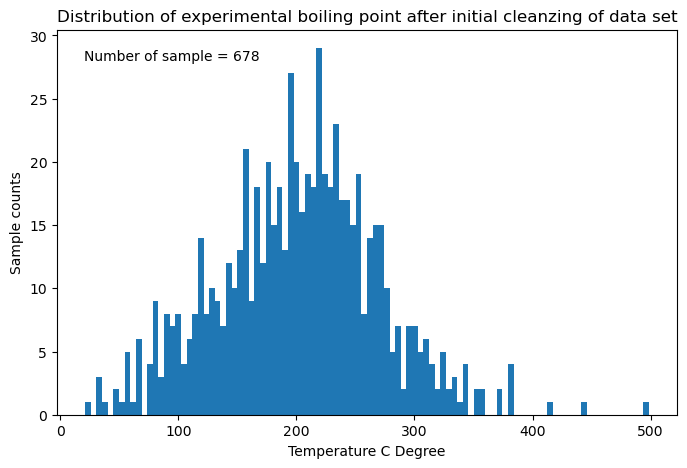

In [227]:
# distribution of boiling point


bp_exp = bp_df['bp_c_pubchem'].values
numSample = bp_df.shape[0]

plt.figure(figsize=(8, 5))
plt.hist(bp_exp, bins=100)
plt.title('Distribution of experimental boiling point after initial cleanzing of data set')
plt.xlabel('Temperature C Degree')
plt.ylabel('Sample counts')
plt.text(x=20.0, y= 28.0, s=f'Number of sample = {numSample}')
plt.show()

In [229]:
# now i want to merge bp_df with dragon df
dragon_df = pd.read_csv('data/raw_dragon_matrix.csv') # dragon_df is the dataframe with dragon features
dragon_df.head(10)


,CID,MW,AMW,Sv,Se,Sp,Si,Mv,Me,Mp,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,126,122.130000,8.142,10.010,15.3050,10.193000,16.664000,0.667,1.020,0.680,...,66.806000,113.420000,0.864,-2.37,-2.42,-2.39,1.0,40.0,0.000,0
1,176,60.060000,7.507,4.483,8.4220,4.896675,9.249000,0.560,1.053,0.554,...,36.165462,58.100000,0.684,-1.06,-0.95,-0.84,0.0,12.0,0.000,0
2,177,57.375125,6.294,4.483,7.7353,4.896675,8.566025,0.538,1.013,0.568,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.000,0
3,179,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,1.014,0.568,...,54.205000,92.700000,0.717,-1.20,-1.11,-1.00,0.0,22.0,0.000,0
4,180,58.090000,5.809,5.295,9.9780,5.739000,11.455000,0.530,0.998,0.574,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.000,0
5,240,106.130000,7.581,9.295,13.9780,9.739000,15.455000,0.664,0.998,0.696,...,62.810000,104.630000,0.919,-2.89,-3.00,-3.00,1.0,34.0,0.000,0
6,261,72.120000,5.548,6.822,12.8620,7.500000,14.870000,0.525,0.989,0.577,...,50.209000,83.910000,0.790,-1.95,-1.94,-1.88,0.0,14.0,0.000,0
7,263,74.140000,4.943,7.349,14.7450,8.261000,17.285000,0.490,0.983,0.551,...,53.136000,86.550000,0.747,-2.07,-2.08,-2.03,0.0,14.0,0.000,0
8,264,88.120000,6.294,7.537,14.1890,7.955000,16.080000,0.538,1.014,0.568,...,54.205000,92.700000,0.751,-1.89,-1.88,-1.82,0.0,20.0,0.000,0
9,307,132.170000,7.343,11.822,17.8620,12.500000,19.870000,0.657,0.992,0.694,...,79.067000,136.590000,0.922,-3.15,-3.28,-3.30,1.0,42.0,0.026,0


In [230]:
# merge bp_df and dragon_df
bp_dragon_df = pd.merge(
    bp_df,
    dragon_df,
    left_on='CID',
    right_on='CID',
    how='left'
)

bp_dragon_df = bp_dragon_df.loc[bp_dragon_df['bp_c_pubchem'].notna()]
bp_dragon_df.shape


(678, 2496)

In [231]:
# how many samples have missing values
numRows_missing_fetures = bp_dragon_df[bp_dragon_df.isna().any(axis=1)].shape[0]
print(f"numRows_missing_fetures: {numRows_missing_fetures}")


numRows_missing_fetures: 64


In [232]:
# after merge i want to remove samples with missing values
bp_dragon_df = bp_dragon_df.dropna()
bp_dragon_df.shape


(614, 2496)

In [233]:
bp_dragon_df.head(10)

,moodifyindex(mi),CID,bp_c_pubchem,bp_raw_pubchem_clean,pubchem_title_clean,bp_pressure_reason,MW,AMW,Sv,Se,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,1000983,177,21.111,"70 °F at 760 mmHg (NTP, 1992)",Acetaldehyde,explicit_standard_pressure,57.375125,6.294,4.483,7.7353,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.0,0.0
1,1001071,7865,31.500,"88.7 °F at 760 mmHg (NTP, 1992)",Methyl formate,explicit_standard_pressure,60.060000,7.507,4.483,8.4220,...,36.165462,58.100000,0.718,-1.06,-0.95,-0.84,0.0,10.0,0.0,0.0
2,1001072,6363,32.389,"90.3 °F at 760 mmHg (NTP, 1992)",Isopropylamine,explicit_standard_pressure,59.130000,4.573,6.129,12.6360,...,46.342000,71.460000,0.789,-1.68,-1.65,-1.58,0.0,12.0,0.0,0.0
3,1004175,6343,34.389,"93.9 °F at 760 mmHg (USCG, 1999)",Ethanethiol,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.780,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0
4,1002831,1068,37.222,"99 °F at 760 mmHg (USCG, 1999)",Dimethyl Sulfide,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.785,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0
5,1001165,7852,47.500,47.00 to 48.00 °C. @ 760.00 mm Hg,Propylamine,explicit_standard_pressure,59.130000,4.573,6.129,12.6360,...,46.342000,71.460000,0.814,-1.68,-1.65,-1.58,0.0,10.0,0.0,0.0
6,1001136,527,48.889,"120 °F at 760 mmHg (NTP, 1992)",Propanal,explicit_standard_pressure,58.090000,5.809,5.295,9.9780,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,10.0,0.0,0.0
7,1001131,8025,53.000,52.00 to 54.00 °C. @ 760.00 mm Hg,Ethyl formate,explicit_standard_pressure,74.090000,6.735,6.010,11.3050,...,44.613000,75.400000,0.753,-1.50,-1.45,-1.36,0.0,14.0,0.0,0.0
8,1001103,180,56.500,56.00 to 57.00 °C. @ 760.00 mm Hg,Acetone,explicit_standard_pressure,58.090000,5.809,5.295,9.9780,...,40.616000,66.610000,0.766,-1.56,-1.51,-1.43,0.0,12.0,0.0,0.0
9,1000958,6584,56.889,"134.4 °F at 760 mmHg (NTP, 1992)",Methyl Acetate,explicit_standard_pressure,74.090000,6.735,6.010,11.3050,...,44.613000,75.400000,0.753,-1.50,-1.45,-1.36,0.0,16.0,0.0,0.0


In [234]:
all_dragon_features_names = dragon_df.columns.tolist()[6:]
mX = bp_dragon_df.loc[:, 'MW':].astype(float).values # mX is the dataframe with all dragon features
mX_std = StandardScaler().fit_transform(mX) # standardize the features
print(f"mX_std.shape: {mX_std.shape}")

vY = bp_dragon_df['bp_c_pubchem'].values
print(f"vY.shape: {vY.shape}")

mX_std.shape: (614, 2490)
vY.shape: (614,)


In [236]:
bp_dragon_df.sort_values(by='bp_c_pubchem').head(5)

,moodifyindex(mi),CID,bp_c_pubchem,bp_raw_pubchem_clean,pubchem_title_clean,bp_pressure_reason,MW,AMW,Sv,Se,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,1000983,177,21.111,"70 °F at 760 mmHg (NTP, 1992)",Acetaldehyde,explicit_standard_pressure,57.375125,6.294,4.483,7.7353,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.0,0.0
1,1001071,7865,31.500,"88.7 °F at 760 mmHg (NTP, 1992)",Methyl formate,explicit_standard_pressure,60.060000,7.507,4.483,8.4220,...,36.165462,58.100000,0.718,-1.06,-0.95,-0.84,0.0,10.0,0.0,0.0
2,1001072,6363,32.389,"90.3 °F at 760 mmHg (NTP, 1992)",Isopropylamine,explicit_standard_pressure,59.130000,4.573,6.129,12.6360,...,46.342000,71.460000,0.789,-1.68,-1.65,-1.58,0.0,12.0,0.0,0.0
3,1004175,6343,34.389,"93.9 °F at 760 mmHg (USCG, 1999)",Ethanethiol,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.780,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0
4,1002831,1068,37.222,"99 °F at 760 mmHg (USCG, 1999)",Dimethyl Sulfide,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.785,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0


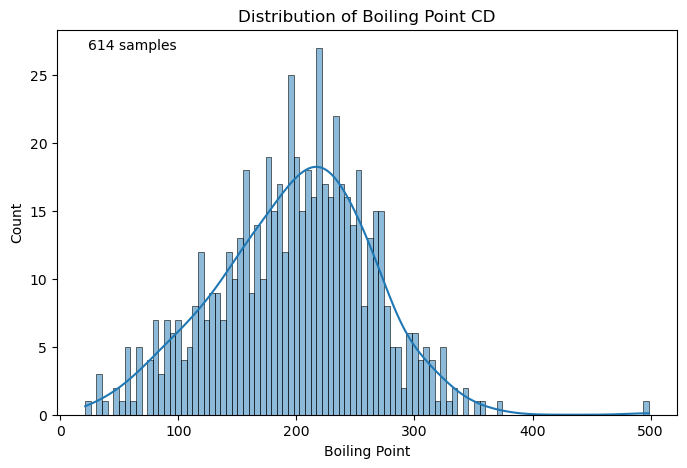

In [238]:
# distribution of boiling point
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram + KDE curve
plt.figure(figsize=(8, 5))
sns.histplot(vY, bins=100, kde=True)
plt.text(0.05, 0.95, f'{len(vY)} samples', transform=plt.gca().transAxes)
plt.xlabel('Boiling Point')
plt.ylabel('Count')
plt.title('Distribution of Boiling Point CD')
plt.show()

In [239]:
# Step 1: sanity check
assert mX_std.shape[0] == vY.shape[0]
assert not np.isnan(mX_std).any()
assert not np.isnan(vY).any()

print(f"Features: {mX_std.shape}")
print(f"Target:   min={vY.min():.1f}, max={vY.max():.1f}, mean={vY.mean():.1f} °C")
print(f"           std={vY.std():.1f} °C")

Features: (614, 2490)
Target:   min=21.1, max=498.5, mean=198.7 °C
           std=64.7 °C


In [240]:
# Baseline model Dummy Regressor

# Same CV style as regression_for_Imax.ipynb (leave-one-out style on full set)
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42)
oDummy = DummyRegressor(strategy="mean")
vY_pred_dummy = cross_val_predict(oDummy, mX_std, vY, cv=kf)
mae_dummy = mean_absolute_error(vY, vY_pred_dummy)
r2_dummy = r2_score(vY, vY_pred_dummy)
print(f"Dummy (mean) — CV MAE: {mae_dummy:.2f} °C")
print(f"Dummy (mean) — CV R²:  {r2_dummy:.2f}")

Dummy (mean) — CV MAE: 51.58 °C
Dummy (mean) — CV R²:  -0.00


In [241]:
# Now, strightforward linear regression 
from sklearn.linear_model import LinearRegression

oLinReg = LinearRegression()
vY_pred_lr = cross_val_predict(oLinReg, mX_std, vY, cv=kf)

mae_lr = mean_absolute_error(vY, vY_pred_lr)
r2_lr = r2_score(vY, vY_pred_lr)

print(f"Linear regression — CV MAE: {mae_lr:.2f} °C")
print(f"Linear regression — CV R²:  {r2_lr:.2f}")
print(f"Improvement vs dummy:       {mae_dummy - mae_lr:.2f} °C MAE")

Linear regression — CV MAE: 32.78 °C
Linear regression — CV R²:  0.49
Improvement vs dummy:       18.80 °C MAE


In [ ]:
# Try retrieve the relevant descriptors according to the common knoledge and ref2
from ml_feature_matrix import build_ml_feature_matrix, raw_features_slice

feat_dict = {
    "f1_mass": 1,
    "f2_lipophilicity": 1,
    "f3_lipophilicity_extended": 4,
    "f4_volume": 1,
    "f5_volume": 1,
    "f6_volume": 1,
    "f7_surface_shape_Mor": 7,
    "f8_surface_shape_RDF": 8,
    "f9_whim": 4,
    "f10_geometry_topology": 8,
    "f11_spatial_autocorrelation": 8,
    "f12_polarity": 1,
    "f13_p_vsa_logp": 5,
    "f14_spdiam": 4,
}

features_df = raw_features_slice(bp_dragon_df, start_col="MW")
X_ml = build_ml_feature_matrix(features_df, feat_dict)  

# Optional: keep IDs + target aligned (same pattern as features_set_1)
bp_features_df = pd.concat(
    [bp_dragon_df[["moodifyindex(mi)", "CID", "bp_c_pubchem"]], X_ml],
    axis=1,
)

# Matrix for sklearn (same as classifications_trials / regression_for_Imax)
features_df = raw_features_slice(bp_dragon_df, start_col="MW")
X_ml = build_ml_feature_matrix(features_df, feat_dict)
mX_54 = X_ml.loc[:, "f1_mass_PC1":].astype(float).values
print(mX_54.shape)

(614, 54)


In [243]:
# Repeat dummy on 54 features
vY_pred_dummy_54 = cross_val_predict(oDummy, mX_54, vY, cv=kf)
print("Dummy 54 — CV MAE:", mean_absolute_error(vY, vY_pred_dummy_54))
print("Dummy 54 — CV R²: ", r2_score(vY, vY_pred_dummy_54))


Dummy 54 — CV MAE: 51.58349946596809
Dummy 54 — CV R²:  -0.003265303950032994


In [244]:
# Linear regression
vY_pred_lr_54 = cross_val_predict(oLinReg, mX_54, vY, cv=kf)
mae_lr_54 = mean_absolute_error(vY, vY_pred_lr_54)
r2_lr_54 = r2_score(vY, vY_pred_lr_54)
print("Linear 54 — CV MAE:", mae_lr_54)
print("Linear 54 — CV R²: ", r2_lr_54)
print("vs dummy MAE improvement:", 58.91 - mae_lr_54)

Linear 54 — CV MAE: 18.14306068208647
Linear 54 — CV R²:  0.7867126909014839
vs dummy MAE improvement: 40.766939317913526


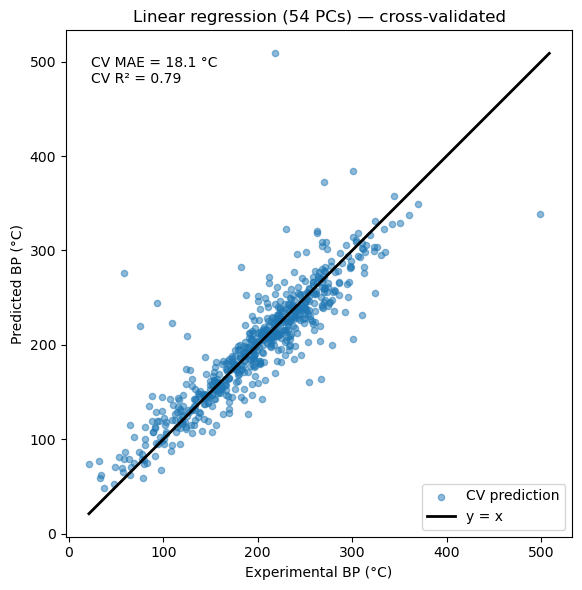

In [245]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vY, vY_pred_lr_54, alpha=0.5, s=20, label="CV prediction")
lims = [min(vY.min(), vY_pred_lr_54.min()), max(vY.max(), vY_pred_lr_54.max())]
ax.plot(lims, lims, "k-", lw=2, label="y = x")
ax.set_xlabel("Experimental BP (°C)")
ax.set_ylabel("Predicted BP (°C)")
ax.set_title("Linear regression (54 PCs) — cross-validated")
ax.text(0.05, 0.95, f"CV MAE = {mae_lr_54:.1f} °C\nCV R² = {r2_lr_54:.2f}",
        transform=ax.transAxes, va="top")
ax.legend()
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [246]:
oLinReg.fit(mX_54, vY)
vY_pred_in = oLinReg.predict(mX_54)
mae_in = mean_absolute_error(vY, vY_pred_in)
r2_in = r2_score(vY, vY_pred_in)
print(f"In-sample  — MAE: {mae_in:.2f} °C, R²: {r2_in:.2f}")
print(f"CV         — MAE: {mae_lr_54:.2f} °C, R²: {r2_lr_54:.2f}")

In-sample  — MAE: 15.76 °C, R²: 0.86
CV         — MAE: 18.14 °C, R²: 0.79


In [247]:
# decide to go for kernel SVR with current 54 features

# Same grid spirit as svr_kernel_Imax.ipynb
vC = [0.01, 0.1, 1, 10, 100, 1000]
vEpsilon = [0.01, 0.05, 0.1, 0.5, 1.0]
vGamma = ["scale", "auto", 0.001, 0.01, 0.1, 1]
lParamGrid = [
  {
    "svr__kernel": ["linear"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
  },
  {
    "svr__kernel": ["rbf"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": vGamma,
  },
  {
    "svr__kernel": ["poly"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.001, 0.01, 0.1],
    "svr__degree": [2, 3, 4],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
  {
    "svr__kernel": ["sigmoid"],
    "svr__C": vC,
    "svr__epsilon": vEpsilon,
    "svr__gamma": ["scale", "auto", 0.01, 0.1, 1],
    "svr__coef0": [0.0, 0.1, 1.0],
  },
]

pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(max_iter=50_000)),
])

kf_tune = KFold(n_splits=100, shuffle=True, random_state=42)


In [248]:
oGsSvr = GridSearchCV(
    estimator=pipe_svr,
    param_grid=lParamGrid,
    scoring="neg_mean_absolute_error",
    cv=kf_tune,
    n_jobs=-1,
    refit=True,
    verbose=4,
)
oGsSvr.fit(mX_54, vY)
print(f"Best CV MAE (100-fold): {-oGsSvr.best_score_:.2f} °C")
print("Best parameters:", oGsSvr.best_params_)

Fitting 100 folds for each of 2010 candidates, totalling 201000 fits
Best CV MAE (100-fold): 14.52 °C
Best parameters: {'svr__C': 1000, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}


In [249]:
cv = pd.DataFrame(oGsSvr.cv_results_)
cv["mae"] = -cv["mean_test_score"]
top = cv.nsmallest(15, "mae")[
    ["param_svr__kernel", "param_svr__C", "param_svr__epsilon",
     "param_svr__gamma", "param_svr__degree", "param_svr__coef0", "mae", "std_test_score"]
]
display(top)

,param_svr__kernel,param_svr__C,param_svr__epsilon,param_svr__gamma,param_svr__degree,param_svr__coef0,mae,std_test_score
195,rbf,1000.0,0.10,0.01,NaN,NaN,14.519391,7.766054
189,rbf,1000.0,0.05,0.01,NaN,NaN,14.519701,7.769071
183,rbf,1000.0,0.01,0.01,NaN,NaN,14.522234,7.771422
201,rbf,1000.0,0.50,0.01,NaN,NaN,14.566504,7.744299
207,rbf,1000.0,1.00,0.01,NaN,NaN,14.579313,7.729125
1288,poly,100.0,0.01,0.01,3.0,1.0,14.782133,8.074963
1293,poly,100.0,0.05,0.01,3.0,1.0,14.785570,8.071170
1298,poly,100.0,0.10,0.01,3.0,1.0,14.791886,8.067319
1308,poly,100.0,1.00,0.01,3.0,1.0,14.830686,7.907663
1303,poly,100.0,0.50,0.01,3.0,1.0,14.867262,8.026055


In [251]:
# Optional: LOOCV for final comparison to linear (slower)
kf_eval = KFold(n_splits=len(vY), shuffle=True, random_state=42)
# Or reuse kf_tune for faster comparison:
# kf_eval = kf_tune

vY_pred_svr = cross_val_predict(oGsSvr.best_estimator_, mX_54, vY, cv=kf_eval)

mae_svr = mean_absolute_error(vY, vY_pred_svr)
r2_svr = r2_score(vY, vY_pred_svr)

print(f"SVR — CV MAE: {mae_svr:.2f} °C")
print(f"SVR — CV R²:  {r2_svr:.2f}")
print(f"Linear 54 — CV MAE was ~18.14 °C")
print(f"Improvement vs linear: {18.14 - mae_svr:.2f} °C MAE")

SVR — CV MAE: 14.48 °C
SVR — CV R²:  0.84
Linear 54 — CV MAE was ~18.14 °C
Improvement vs linear: 3.66 °C MAE


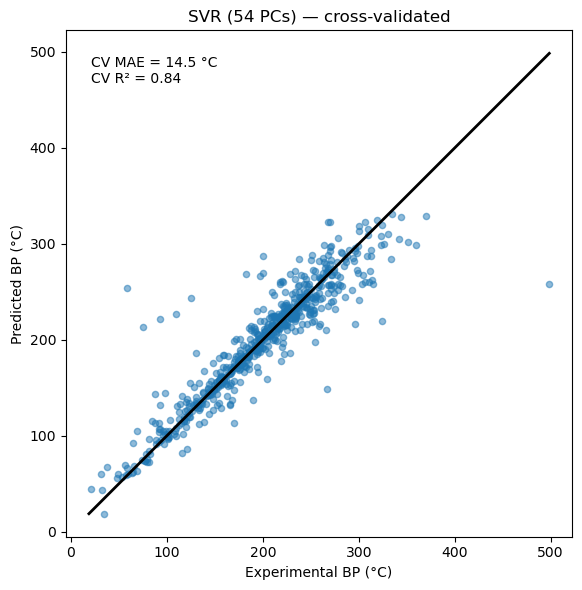

In [ ]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vY, vY_pred_svr, alpha=0.5, s=20)
lims = [min(vY.min(), vY_pred_svr.min()), max(vY.max(), vY_pred_svr.max())]
ax.plot(lims, lims, "k-", lw=2)
ax.set_xlabel("Experimental BP (°C)")
ax.set_ylabel("Predicted BP (°C)")
ax.set_title("SVR (54 PCs) — cross-validated")
ax.text(0.05, 0.95, f"CV MAE = {mae_svr:.1f} °C\nCV R² = {r2_svr:.2f}",
        transform=ax.transAxes, va="top")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [253]:
# Best parameters: {'svr__C': 1000, 'svr__epsilon': 0.1, 'svr__gamma': 0.01, 'svr__kernel': 'rbf'}
n_feat = mX_54.shape[1]
# Approximate value of gamma='scale' on standardized X (var ≈ 1 per feature)
gamma_scale_approx = 1.0 / n_feat
pipe_svr = Pipeline([
    ("scaler", StandardScaler()),
    ("svr", SVR(max_iter=50_000)),
])
kf_tune = KFold(n_splits=len(vY), shuffle=True, random_state=42)
lParamGrid_refine = [
    {
        "svr__kernel": ["rbf"],
        "svr__C": [300, 1000, 3000],
        "svr__epsilon": [0.01, 0.05, 0.1, 0.2],
        "svr__gamma": [
            0.005, 0.01, gamma_scale_approx, 0.03, 0.05, 0.1,
            "scale", "auto",
        ],
    }
]
oGsSvr_refine = GridSearchCV(
    estimator=pipe_svr,
    param_grid=lParamGrid_refine,
    scoring="neg_mean_absolute_error",
    cv=kf_tune,
    n_jobs=-1,
    refit=True,
    verbose=4,
)
oGsSvr_refine.fit(mX_54, vY)
print(f"Previous best CV MAE: 35.15 °C (your run)")
print(f"Refined best CV MAE:  {-oGsSvr_refine.best_score_:.2f} °C")
print("Refined best params:", oGsSvr_refine.best_params_)

Fitting 614 folds for each of 96 candidates, totalling 58944 fits
Previous best CV MAE: 35.15 °C (your run)
Refined best CV MAE:  13.72 °C
Refined best params: {'svr__C': 1000, 'svr__epsilon': 0.01, 'svr__gamma': 0.005, 'svr__kernel': 'rbf'}


In [254]:
vY_pred_svr_tune = cross_val_predict(oGsSvr_refine.best_estimator_, mX_54, vY, cv=kf_tune)

cv_mae_svr_tune = mean_absolute_error(vY, vY_pred_svr_tune)
print(f"Tuned SVR MAE: {cv_mae_svr_tune:.2f}")

cv_r2_scr_tune = r2_score(vY, vY_pred_svr_tune)
print(f"Tuned SVR r2: {cv_r2_scr_tune:.2f}")


Tuned SVR MAE: 13.72
Tuned SVR r2: 0.85


In [255]:
bp_dragon_df.head()

,moodifyindex(mi),CID,bp_c_pubchem,bp_raw_pubchem_clean,pubchem_title_clean,bp_pressure_reason,MW,AMW,Sv,Se,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,1000983,177,21.111,"70 °F at 760 mmHg (NTP, 1992)",Acetaldehyde,explicit_standard_pressure,57.375125,6.294,4.483,7.7353,...,36.165462,58.069625,0.729,-1.12,-1.02,-0.91,0.0,6.0,0.0,0.0
1,1001071,7865,31.500,"88.7 °F at 760 mmHg (NTP, 1992)",Methyl formate,explicit_standard_pressure,60.060000,7.507,4.483,8.4220,...,36.165462,58.100000,0.718,-1.06,-0.95,-0.84,0.0,10.0,0.0,0.0
2,1001072,6363,32.389,"90.3 °F at 760 mmHg (NTP, 1992)",Isopropylamine,explicit_standard_pressure,59.130000,4.573,6.129,12.6360,...,46.342000,71.460000,0.789,-1.68,-1.65,-1.58,0.0,12.0,0.0,0.0
3,1004175,6343,34.389,"93.9 °F at 760 mmHg (USCG, 1999)",Ethanethiol,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.780,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0
4,1002831,1068,37.222,"99 °F at 760 mmHg (USCG, 1999)",Dimethyl Sulfide,explicit_standard_pressure,62.150000,6.906,4.767,8.7270,...,41.086000,61.670000,0.785,-2.11,-2.12,-2.07,0.0,6.0,0.0,0.0


In [258]:
df_res = bp_dragon_df[['moodifyindex(mi)','CID', 'pubchem_title_clean', 'bp_c_pubchem' ]].copy()
df_res['bp_exp'] = vY
df_res['bp_pred'] = vY_pred_svr_tune
df_res['residual'] = df_res['bp_exp'] - df_res['bp_pred']
df_res["abs_err"] = df_res["residual"].abs()

# Top 20 worst
display(df_res.nlargest(20, "abs_err")[
    ["CID", "bp_exp", "bp_pred", "residual"]
])



,CID,bp_exp,bp_pred,residual
674,638024,498.500,288.185618,210.314382
11,61124,58.500,265.971622,-207.471622
45,8369,92.778,234.951453,-142.173453
22,7165,75.500,213.850029,-138.350029
566,7768,266.889,144.839153,122.049847
68,36822,109.500,223.102739,-113.602739
63,643820,125.000,236.143855,-111.143855
389,6374,217.778,315.183908,-97.405908
630,24433,182.222,279.461669,-97.239669
650,10947,324.500,235.194818,89.305182


In [259]:
df_res.sort_values(by='CID').head(20)

,moodifyindex(mi),CID,pubchem_title_clean,bp_c_pubchem,bp_exp,bp_pred,residual,abs_err
600,1001383,107,Benzenepropanoic acid,280.000,280.000,267.268707,12.731293,12.731293
526,1001444,125,4-Hydroxybenzyl Alcohol,252.000,252.000,273.228874,-21.228874,21.228874
639,1000419,126,4-Hydroxybenzaldehyde,310.500,310.500,258.570616,51.929384,51.929384
81,1000241,176,Acetic Acid,117.778,117.778,120.983609,-3.205609,3.205609
0,1000983,177,Acetaldehyde,21.111,21.111,38.950064,-17.839064,17.839064
142,1002770,179,Acetoin,147.500,147.500,147.817257,-0.317257,0.317257
8,1001103,180,Acetone,56.500,56.500,60.296813,-3.796813,3.796813
240,1000001,240,Benzaldehyde,178.889,178.889,185.086823,-6.197823,6.197823
518,1000421,243,Benzoic Acid,248.889,248.889,225.914820,22.974180,22.974180
341,1000448,244,Benzyl Alcohol,205.500,205.500,197.895378,7.604622,7.604622


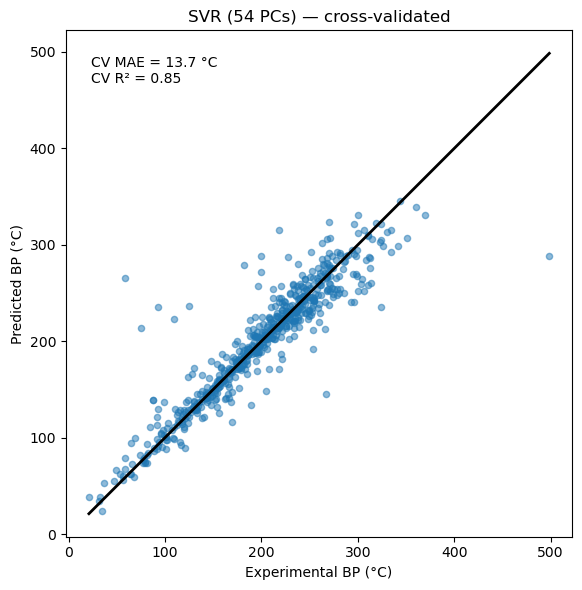

In [261]:
# Visualization of tuned SVR estimator

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(vY, vY_pred_svr_tune, alpha=0.5, s=20)
lims = [min(vY.min(), vY_pred_svr_tune.min()), max(vY.max(), vY_pred_svr_tune.max())]
ax.plot(lims, lims, "k-", lw=2)
ax.set_xlabel("Experimental BP (°C)")
ax.set_ylabel("Predicted BP (°C)")
ax.set_title("SVR (54 PCs) — cross-validated")
ax.text(0.05, 0.95, f"CV MAE = {cv_mae_svr_tune:.1f} °C\nCV R² = {cv_r2_scr_tune:.2f}",
        transform=ax.transAxes, va="top")
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.show()

In [263]:
waka_df = pd.read_csv('data/waka_with_CID.csv')
waka_df.head()

,Unnamed: 0,CID,CAS,Name,Imax,Ci,Di
0,0,162268,37609-25-9,(5Z)-cyclohexadec-5-en-1-one,14.50,-2.48,0.27
1,1,2758,470-82-6,"1,8-cineol",58.98,1.41,0.86
2,2,8187,112-45-8,10-undecenal,60.03,0.29,0.75
3,3,18827,3391-86-4,1-octen-3-ol,41.28,0.93,0.62
4,4,17121,2442-10-6,1-octen-3-yl acetate,54.08,1.66,0.87


In [298]:
waka_res_merged_df = pd.merge(
    waka_df[['CID', 'Imax']],
    df_res,
    how='left',
    on='CID'
)
print(f'waka_res_merged_df shape {waka_res_merged_df.shape}')
print(f'Number of rows with BP data: {waka_res_merged_df['bp_exp'].notna().sum()}')
waka_res_merged_df.head(5)

waka_res_merged_df shape (312, 9)
Number of rows with BP data: 129


,CID,Imax,moodifyindex(mi),pubchem_title_clean,bp_c_pubchem,bp_exp,bp_pred,residual,abs_err
0,162268,14.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2758,58.98,1000037.0,"1,8-Cineole",176.667,176.667,189.44424,-12.77724,12.77724
2,8187,60.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18827,41.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17121,54.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN


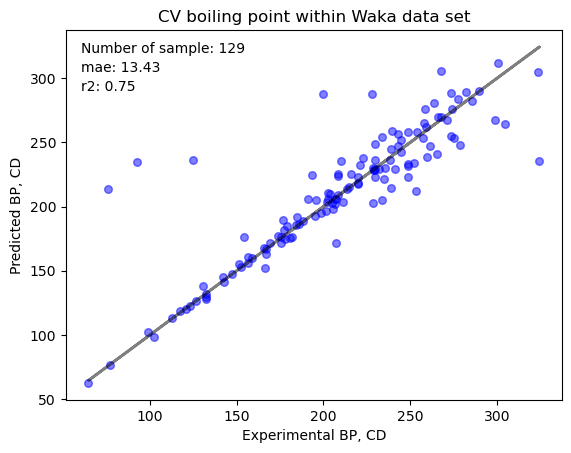

In [275]:
# want to visualize the data of BP only from Wakayama data set

waka_bp_exp = waka_res_merged_df['bp_exp'].loc[waka_res_merged_df['bp_exp'].notna()].values
waka_bp_pred = waka_res_merged_df['bp_pred'].loc[waka_res_merged_df['bp_pred'].notna()].values
waka_mae = mean_absolute_error(waka_bp_exp, waka_bp_pred)
waka_r2 = r2_score(waka_bp_exp, waka_bp_pred)

fig, ax = plt.subplots()
ax.scatter(waka_bp_exp, waka_bp_pred, s= 30, color = 'blue', alpha=0.5)
ax.plot(waka_bp_exp, waka_bp_exp, lw=2, color = 'k', alpha=0.5)
ax.set_title('CV boiling point within Waka data set')
ax.set_xlabel('Experimental BP, CD')
ax.set_ylabel('Predicted BP, CD')
ax.text(60.0, 320.0, f'Number of sample: {len(waka_bp_exp)}')
ax.text(60.0, 305.0, f'mae: {waka_mae:.2f}')
ax.text(60.0, 290.0, f'r2: {waka_r2:.2f}')

plt.show()



In [302]:
# vY_pred_svr_tune = cross_val_predict(oGsSvr_refine.best_estimator_, mX_54, vY, cv=kf_tune)

# now, i want to predict boiling points walues for ingredients im wakayama dataset without experimental values

to_predict_df = waka_res_merged_df.loc[waka_res_merged_df['bp_exp'].isna()]
print(f'Num of samples to predict bp from Waka data set {to_predict_df.shape[0]}')
to_predict_df.head(5)

Num of samples to predict bp from Waka data set 183


,CID,Imax,moodifyindex(mi),pubchem_title_clean,bp_c_pubchem,bp_exp,bp_pred,residual,abs_err
0,162268,14.50,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,8187,60.03,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,18827,41.28,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,17121,54.08,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,21895,40.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [304]:
to_predict_dragon_merged = pd.merge(
    to_predict_df['CID'],
    dragon_df,
    how='left',
    on='CID'
)
print(f'shape of the to_predict_dragon_merged is {to_predict_dragon_merged.shape} ')
to_predict_dragon_merged.head(5)

shape of the to_predict_dragon_merged is (183, 2491) 


,CID,MW,AMW,Sv,Se,Sp,Si,Mv,Me,Mp,...,VvdwMG,VvdwZAZ,PDI,BLTF96,BLTD48,BLTA96,nCIR,ZM1,R8u_,nRCOSR
0,162268,236.44,5.254,24.090,43.698,27.114,51.022,0.535,0.971,0.603,...,154.996,276.51,0.898,-4.67,-4.99,-5.09,1.0,70.0,0.021,0.0
1,8187,168.31,5.260,16.983,31.163,19.069,36.361,0.531,0.974,0.596,...,114.428,202.37,0.853,-3.88,-4.11,-4.16,0.0,42.0,0.019,0.0
2,18827,128.24,5.130,12.929,24.396,14.546,28.531,0.517,0.976,0.582,...,88.578,153.11,0.789,-3.20,-3.34,-3.36,0.0,32.0,0.029,0.0
3,17121,170.28,5.676,16.171,29.607,17.762,34.156,0.539,0.987,0.592,...,108.832,193.86,0.835,-3.58,-3.76,-3.80,0.0,46.0,0.026,0.0
4,21895,194.25,6.937,16.832,28.167,17.693,31.535,0.601,1.006,0.632,...,104.706,181.69,0.897,-2.35,-2.40,-2.36,2.0,68.0,0.029,0.0


In [ ]:
# next step is to build proper feature matrix

features_df = raw_features_slice(to_predict_dragon_merged, start_col="MW")
X_ml = build_ml_feature_matrix(features_df, feat_dict)
mX_54_to_predict = X_ml.loc[:, "f1_mass_PC1":].astype(float).values


In [312]:
bp_prod_pred = oGsSvr_refine.best_estimator_.predict(mX_54_to_predict)
bp_prod_pred

array([266.90425327, 216.60311997, 175.63701785, 193.92259598,
       233.48915999, 156.12329851, 146.54918698, 180.17017586,
       178.57637595, 291.75694511, 261.74270337, 240.70509254,
       270.18396185, 185.01238288, 255.12771519, 265.87715207,
       272.2495832 , 185.01238288, 185.01238288, 191.94936209,
       256.8349912 , 269.75511763, 274.4956524 , 228.35449778,
       210.54267477, 189.03038896, 212.5333639 , 265.46821619,
       209.05912105, 185.01238288, 185.01238288, 252.27695736,
       235.26526698, 257.46442602, 185.01238288, 169.54728177,
       243.00211954, 273.33678091, 185.01238288, 276.18862416,
       185.01238288, 190.00478042, 117.13682733, 240.66375449,
       161.26369114, 191.78650435, 172.53993178, 185.01238288,
       180.75909856, 137.16995749, 110.97192142, 126.12213786,
       121.10427401, 204.62953578, 137.24400975, 153.79645883,
       187.15953885, 282.78395379, 200.40004303, 196.6843248 ,
       210.3871809 , 181.82103085, 211.7614722 , 179.41

In [328]:
predicted_bp_df = to_predict_dragon_merged[['CID']].copy()
predicted_bp_df['bp_prod_pred'] = bp_prod_pred
predicted_bp_df.head()

,CID,bp_prod_pred
0,162268,266.904253
1,8187,216.603120
2,18827,175.637018
3,17121,193.922596
4,21895,233.489160


In [329]:
# i want to create waka_bp_impute df
waka_bp_impute = waka_res_merged_df[['CID', 'bp_exp']].copy()
waka_bp_impute = waka_bp_impute.merge(
    predicted_bp_df, 
    how='left',
    on='CID'
)


In [330]:
waka_bp_impute.head(20)

,CID,bp_exp,bp_prod_pred
0,162268,NaN,266.904253
1,2758,176.667,NaN
2,8187,NaN,216.603120
3,18827,NaN,175.637018
4,17121,NaN,193.922596
5,21895,NaN,233.489160
6,8821,NaN,156.123299
7,5362833,NaN,146.549187
8,61031,NaN,180.170176
9,18938,NaN,178.576376


In [331]:
waka_bp_impute['bp_value'] = waka_bp_impute['bp_exp'].fillna(waka_bp_impute['bp_prod_pred'])
# source column (string dtype with missing values)
waka_bp_impute['bp_source'] = pd.Series(pd.NA, index=waka_bp_impute.index, dtype='string')
waka_bp_impute.loc[waka_bp_impute['bp_exp'].notna(), 'bp_source'] = 'experimental'
waka_bp_impute.loc[
    waka_bp_impute['bp_exp'].isna() & waka_bp_impute['bp_prod_pred'].notna(),
    'bp_source'
] = 'predicted'

In [332]:
waka_bp_impute.drop(columns = ['bp_exp', 'bp_prod_pred'], inplace=True)
waka_bp_impute['bp_value'].notna().sum()

np.int64(312)

In [333]:
waka_bp_impute.to_csv('data/waka_with_imputed_bp.csv')

In [ ]:
# now i want to take our best svr estimator Refined best params: 

# and apply Ransac on it

lminSamplesRatio = np.array([0.85, 0.90, 0.93, 0.96, 0.98])

df_ransac = pd.DataFrame({
    'minSampleRatio' : lminSamplesRatio,
    'ransac_mae' : [0.0] * len(lminSamplesRatio),
    'ransac_r2' : [0.0] * len(lminSamplesRatio)
})
df_ransac.head()


,minSampleRatio,ransac_mae,ransac_r2
0,0.85,0.0,0.0
1,0.90,0.0,0.0
2,0.93,0.0,0.0
3,0.96,0.0,0.0
4,0.98,0.0,0.0


In [276]:
# the idea is to find best minsamples ratio

from sklearn.linear_model import RANSACRegressor
# Refined best params: {'svr__C': 1000, 'svr__epsilon': 0.01, 'svr__gamma': 0.005, 'svr__kernel': 'rbf'}
oBestSvrEst = SVR(C=1000, epsilon=0.01, gamma=0.005, kernel='rbf')

kf_ransac = KFold(n_splits=100, shuffle=True, random_state=42)


for i, minSampleRatio in enumerate(lminSamplesRatio):
    print(f'Calcualte model {i} out of {len(df_ransac)} combinations')
    oRansacEst = RANSACRegressor(estimator=oBestSvrEst, min_samples=minSampleRatio, max_trials=100)
    vY_pred_ransac = cross_val_predict(estimator=oRansacEst, X=mX_54, y=vY, cv=kf_ransac)

    df_ransac.loc[i, 'ransac_mae'] = mean_absolute_error(vY, vY_pred_ransac)
    df_ransac.loc[i, 'ransac_r2'] = r2_score(vY, vY_pred_ransac)


Calcualte model 0 out of 5 combinations
Calcualte model 1 out of 5 combinations
Calcualte model 2 out of 5 combinations
Calcualte model 3 out of 5 combinations
Calcualte model 4 out of 5 combinations


In [277]:
df_ransac.sort_values(by= 'ransac_mae', ascending=True).head(20)

,minSampleRatio,ransac_mae,ransac_r2
3,0.96,19.117413,0.779410
2,0.93,19.182742,0.778578
4,0.98,19.191084,0.778286
0,0.85,19.241537,0.775410
1,0.90,19.466347,0.774840


In [294]:
# first i want to implement strightforwasrd LASSO regression

lAlpha = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
kf = KFold(n_splits=len(vY), shuffle=True, random_state=42)

oLasso = Lasso()
params = {
    'alpha': lAlpha
}

oGsLasso = GridSearchCV(
    estimator=oLasso,
    param_grid=params,
    scoring= "neg_mean_absolute_error",
    cv=kf,
    verbose=4,
    n_jobs=-1
)
oGsLasso.fit(mX_54, vY)

Fitting 614 folds for each of 7 candidates, totalling 4298 fits


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.190e+04, tolerance: 2.572e+02
  model = cd_fast.enet_coordinate_descent(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Lasso()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.0001, 0.001, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 :

In [295]:
print(oGsLasso.best_params_)
print(oGsLasso.best_score_)

{'alpha': 0.1}
-18.162827318229315


c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.972e+04, tolerance: 2.571e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.672e+04, tolerance: 2.571e+02
  model = cd_fast.enet_coordinate_descent(
c:\Users\KirilKiriyevsky\PythonMamba\envs\AIProgram\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the

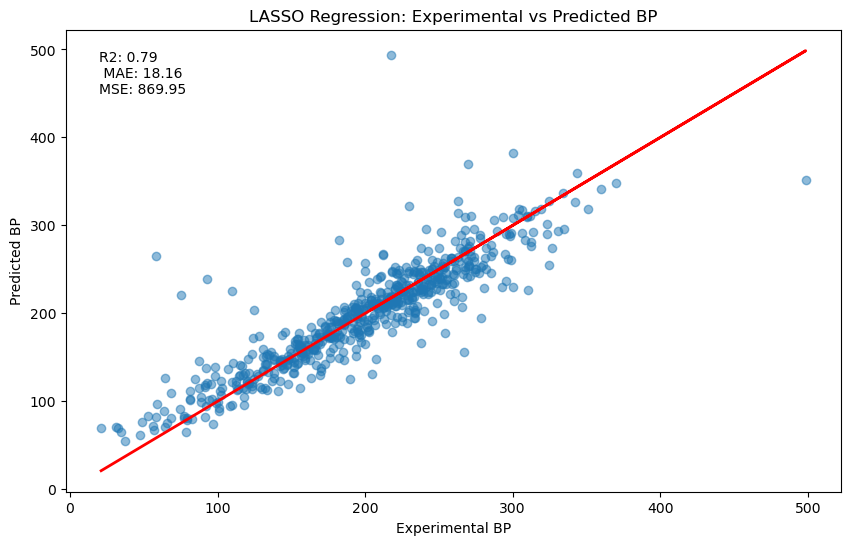

In [297]:
# now i want to visualize the results
plt.figure(figsize=(10, 6))
vY_pred_lasso = cross_val_predict(oGsLasso.best_estimator_, mX_54, vY, cv=kf)
plt.scatter(vY, vY_pred_lasso, alpha=0.5)
plt.plot(vY, vY, color='red', linewidth=2)

r2 = r2_score(vY, vY_pred_lasso)
mae = mean_absolute_error(vY, vY_pred_lasso)
mse = mean_squared_error(vY, vY_pred_lasso)

plt.text(20.0, 450.0, f'R2: {r2:.2f}\n MAE: {mae:.2f}\nMSE: {mse:.2f}')

plt.xlabel('Experimental BP')
plt.ylabel('Predicted BP')
plt.title('LASSO Regression: Experimental vs Predicted BP')
plt.show()

